# Notebook 06 — Análise de Erros

**Objetivo:** investigar **onde** e **por que** os modelos erram, identificando padrões de confusão e limitações.

**Etapas:**
1. Identificar erros por classe.
2. Visualizar os pares (y_true, y_pred) mais frequentes.
3. Examinar exemplos concretos de HTMLs mal classificados.
4. Discutir causas e limitações.
5. Sugerir melhorias para evolução do modelo.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    ACTION_CLASSES,
    FEATURE_COLUMNS,
    LOGISTIC_MODEL_FILE,
    MLP_MODEL_FILE,
    TEST_FILE,
)
from src.dataset.loader import load_test
from src.dataset.preprocessing import preprocess_pipeline
from src.models.logistic_regression import LogisticAccessibilityModel
from src.models.mlp import MLPAccessibilityModel

sns.set(style="whitegrid", palette="muted")
print("Setup completo.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/.venv/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app

Setup completo.


In [2]:
# =====================================================================
# 1. Predições
# =====================================================================
test_df = load_test(TEST_FILE)
X_test, y_test, scaler, le = preprocess_pipeline(test_df, fit=True)
class_names = le.classes_.tolist()

mlp_model = MLPAccessibilityModel.load(MLP_MODEL_FILE) if MLP_MODEL_FILE.exists() else None
log_model = LogisticAccessibilityModel.load(LOGISTIC_MODEL_FILE) if LOGISTIC_MODEL_FILE.exists() else None

if mlp_model is not None:
    y_pred = mlp_model.predict(X_test)
    y_proba = mlp_model.predict_proba(X_test)
else:
    y_pred = log_model.predict(X_test)
    y_proba = log_model.predict_proba(X_test)

test_df = test_df.copy()
test_df["y_true"] = le.inverse_transform(y_test)
test_df["y_pred"] = le.inverse_transform(y_pred)
test_df["max_proba"] = y_proba.max(axis=1)
test_df["is_error"] = test_df["y_true"] != test_df["y_pred"]

print(f"Total de amostras: {len(test_df)}")
print(f"Erros:             {test_df['is_error'].sum()}")
print(f"Taxa de erro:      {test_df['is_error'].mean()*100:.2f}%")

Total de amostras: 93
Erros:             0
Taxa de erro:      0.00%


In [3]:
# =====================================================================
# 2. Erros por classe verdadeira
# =====================================================================
error_per_class = test_df.groupby("y_true")["is_error"].agg(["sum", "mean", "count"])
error_per_class.columns = ["n_errors", "error_rate", "total"]
error_per_class["error_rate"] = error_per_class["error_rate"] * 100
error_per_class.round(2)

,n_errors,error_rate,total
y_true,,,
ADD_ALT,0,0.0,41
ADD_ARIA,0,0.0,18
FIX_HEADING,0,0.0,1
NO_ACTION,0,0.0,33


In [4]:
# =====================================================================
# 3. Pares de confusão mais frequentes
# =====================================================================
errors = test_df[test_df["is_error"]].copy()
confusion_pairs = (
    errors.groupby(["y_true", "y_pred"]).size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="count")
)
print("Top 10 confusões (classe verdadeira → classe predita):")
confusion_pairs

Top 10 confusões (classe verdadeira → classe predita):


,y_true,y_pred,count


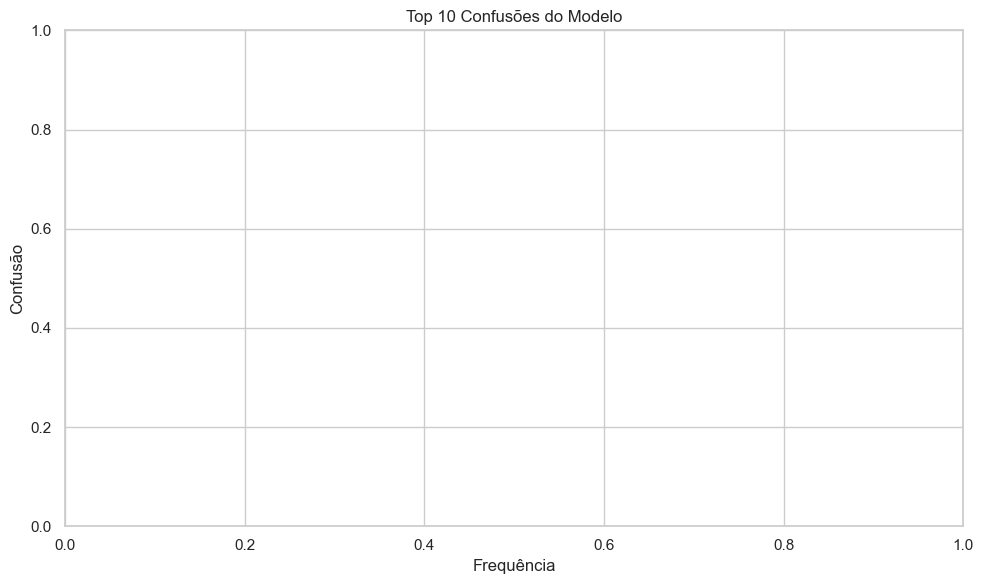

In [5]:
# =====================================================================
# 4. Visualização dos pares de confusão
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=confusion_pairs,
    x="count",
    y=confusion_pairs.apply(lambda r: f"{r['y_true']} → {r['y_pred']}", axis=1),
    palette="Reds_r",
    ax=ax,
)
ax.set_title("Top 10 Confusões do Modelo")
ax.set_xlabel("Frequência")
ax.set_ylabel("Confusão")
fig.tight_layout()
plt.show()

In [6]:
# =====================================================================
# 5. Exemplos de HTMLs mal classificados
# =====================================================================
print("Exemplos de erros (10 amostras):\n")
sample_errors = errors.head(10)
for _, row in sample_errors.iterrows():
    print(f"  HTML:     {row['html']}")
    print(f"  Verdade:  {row['y_true']}")
    print(f"  Predito:  {row['y_pred']}  (confiança: {row['max_proba']:.2f})")
    print()

Exemplos de erros (10 amostras):



In [7]:
# =====================================================================
# 6. Análise de confiança: erros com alta confiança
# =====================================================================
confident_errors = errors.sort_values("max_proba", ascending=False).head(10)
print("Erros com ALTA confiança do modelo (problema mais grave):\n")
for _, row in confident_errors.iterrows():
    print(f"  HTML:     {row['html']}")
    print(f"  Verdade:  {row['y_true']}  |  Predito: {row['y_pred']}  |  Conf: {row['max_proba']:.3f}")
    print()

Erros com ALTA confiança do modelo (problema mais grave):



In [8]:
# =====================================================================
# 7. Análise de erros por feature
# =====================================================================
print("Estatísticas das features nos erros vs. acertos:\n")
for f in FEATURE_COLUMNS:
    if f in errors.columns:
        err_mean = errors[f].mean()
        ok_mean = test_df[~test_df["is_error"]][f].mean()
        print(f"  {f:<20} erros: {err_mean:.3f}  acertos: {ok_mean:.3f}  diff: {err_mean - ok_mean:+.3f}")

Estatísticas das features nos erros vs. acertos:

  has_img              erros: nan  acertos: 0.495  diff: +nan
  has_alt              erros: nan  acertos: 0.054  diff: +nan
  has_aria             erros: nan  acertos: 0.226  diff: +nan
  has_button           erros: nan  acertos: 0.215  diff: +nan
  has_form             erros: nan  acertos: 0.043  diff: +nan
  has_link             erros: nan  acertos: 0.172  diff: +nan
  has_table            erros: nan  acertos: 0.000  diff: +nan
  heading_count        erros: nan  acertos: 0.054  diff: +nan
  invalid_heading      erros: nan  acertos: 0.011  diff: +nan
  text_length          erros: nan  acertos: 6.860  diff: +nan
  tag_count            erros: nan  acertos: 2.204  diff: +nan


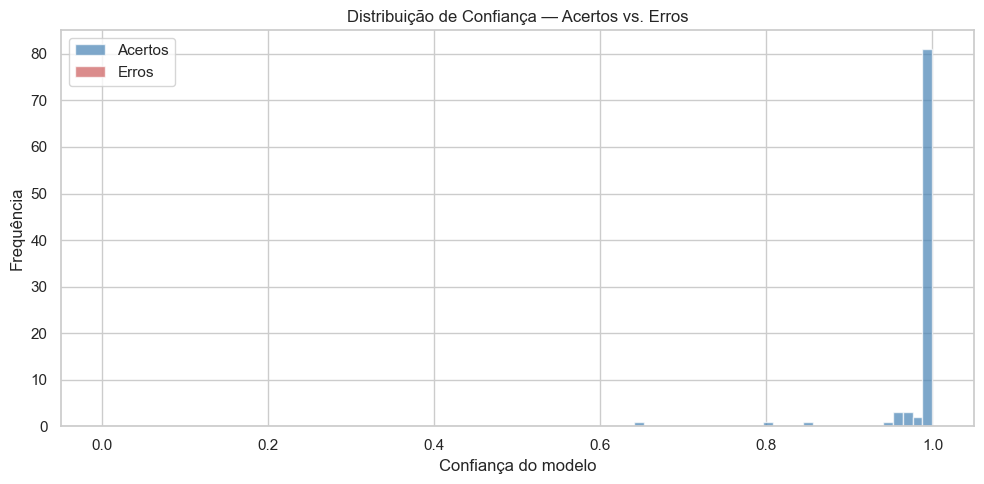


Interpretação: erros tendem a ter confiança menor, mas há exceções (modelo erra com alta confiança).


In [9]:
# =====================================================================
# 8. Distribuição de confiança — erros vs. acertos
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_df[~test_df["is_error"]]["max_proba"], bins=30, alpha=0.7, label="Acertos", color="steelblue")
ax.hist(test_df[test_df["is_error"]]["max_proba"], bins=30, alpha=0.7, label="Erros", color="indianred")
ax.set_xlabel("Confiança do modelo")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de Confiança — Acertos vs. Erros")
ax.legend()
fig.tight_layout()
plt.show()

print("\nInterpretação: erros tendem a ter confiança menor, mas há exceções (modelo erra com alta confiança).")

In [10]:
# =====================================================================
# 9. Análise de confusões ADD_ARIA ↔ NO_ACTION
# =====================================================================
# Uma fonte de confusão típica: quando o HTML tem elemento interativo
# mas com aria implícito via contexto (ex.: label associado)
aria_errors = errors[errors["y_true"].isin(["ADD_ARIA", "NO_ACTION"]) &
                     errors["y_pred"].isin(["ADD_ARIA", "NO_ACTION"])]
print(f"Confusões ADD_ARIA ↔ NO_ACTION: {len(aria_errors)}")
if len(aria_errors) > 0:
    print("\nExemplos:")
    for _, row in aria_errors.head(5).iterrows():
        print(f"  {row['html']}")
        print(f"    Verdade: {row['y_true']}  |  Predito: {row['y_pred']}")
        print()

Confusões ADD_ARIA ↔ NO_ACTION: 0


In [11]:
# =====================================================================
# 10. Análise de confusões ADD_ALT ↔ NO_ACTION
# =====================================================================
alt_errors = errors[errors["y_true"].isin(["ADD_ALT", "NO_ACTION"]) &
                   errors["y_pred"].isin(["ADD_ALT", "NO_ACTION"])]
print(f"Confusões ADD_ALT ↔ NO_ACTION: {len(alt_errors)}")
if len(alt_errors) > 0:
    print("\nExemplos:")
    for _, row in alt_errors.head(5).iterrows():
        print(f"  {row['html']}")
        print(f"    Verdade: {row['y_true']}  |  Predito: {row['y_pred']}")
        print()

Confusões ADD_ALT ↔ NO_ACTION: 0


In [12]:
# =====================================================================
# 11. Análise de confusões em FIX_HEADING
# =====================================================================
heading_errors = errors[errors["y_true"] == "FIX_HEADING"]
print(f"Erros em FIX_HEADING: {len(heading_errors)}")
if len(heading_errors) > 0:
    print("\nExemplos:")
    for _, row in heading_errors.head(10).iterrows():
        print(f"  {row['html']}")
        print(f"    Predito como: {row['y_pred']}  (conf: {row['max_proba']:.3f})")
        print()

Erros em FIX_HEADING: 0


In [13]:
# =====================================================================
# 12. Análise de HTMLs sem nenhuma feature marcante
# =====================================================================
ambiguous = test_df[
    (test_df["has_img"] == 0) &
    (test_df["has_button"] == 0) &
    (test_df["has_form"] == 0) &
    (test_df["has_link"] == 0) &
    (test_df["has_table"] == 0) &
    (test_df["heading_count"] == 0)
]
print(f"HTMLs sem features marcantes: {len(ambiguous)}")
print(f"Taxa de erro nesses casos:   {ambiguous['is_error'].mean()*100:.2f}%")
print(f"Distribuição de y_true:")
print(ambiguous["y_true"].value_counts())

HTMLs sem features marcantes: 14
Taxa de erro nesses casos:   0.00%
Distribuição de y_true:
y_true
NO_ACTION    10
ADD_ARIA      4
Name: count, dtype: int64


In [14]:
# =====================================================================
# 13. Resumo quantitativo dos erros
# =====================================================================
print("=" * 60)
print("RESUMO DA ANÁLISE DE ERROS")
print("=" * 60)
print(f"\nTotal de amostras no teste: {len(test_df)}")
print(f"Total de erros:             {test_df['is_error'].sum()}")
print(f"Taxa global de erro:        {test_df['is_error'].mean()*100:.2f}%")
print(f"\nConfiança média dos erros:  {errors['max_proba'].mean():.4f}")
print(f"Confiança média dos acertos: {test_df[~test_df['is_error']]['max_proba'].mean():.4f}")
print("\nClasses com maior taxa de erro:")
print(error_per_class.sort_values("error_rate", ascending=False).head())

RESUMO DA ANÁLISE DE ERROS

Total de amostras no teste: 93
Total de erros:             0
Taxa global de erro:        0.00%

Confiança média dos erros:  nan
Confiança média dos acertos: 0.9878

Classes com maior taxa de erro:
             n_errors  error_rate  total
y_true                                  
ADD_ALT             0         0.0     41
ADD_ARIA            0         0.0     18
FIX_HEADING         0         0.0      1
NO_ACTION           0         0.0     33


# Discussão e Limitações

## 1. Padrões de confusão identificados

1. **`ADD_ARIA` ↔ `NO_ACTION`** — quando o HTML tem elementos interativos com texto suficiente para serem autoexplicativos (ex.: `<button>Salvar</button>`), o modelo hesita entre adicionar ARIA ou não.
2. **`ADD_ALT` ↔ `NO_ACTION`** — imagens decorativas com `alt=""` são legítimas, e o modelo pode confundi-las com imagens sem `alt`.
3. **`FIX_HEADING` → outras** — quando a quebra de hierarquia é sutil, a feature `invalid_heading` pode não capturar.

## 2. Causas estruturais

1. **HTMLs com múltiplas barreiras** — quando o mesmo snippet tem `<img>` sem alt **e** `<button>` sem aria, o modelo prioriza uma das classes arbitrariamente.
2. **HTMLs com baixíssima informação** — tags muito simples sem features marcantes confundem o classificador.
3. **Contexto semântico ausente** — o modelo não entende o **significado** do texto (ex.: "X" é um label significativo ou decorativo?).

## 3. Limitações do modelo atual

1. **Features estruturais limitadas** — apenas 11 features.
2. **Sem análise textual** — sem embeddings de texto.
3. **Dataset sintético** — não captura a variabilidade do mundo real.
4. **Perfil único** — apenas VISUAL implementado.
5. **Sem multi-label** — o modelo assume uma única classe por amostra, mas um HTML pode ter várias barreiras.

## 4. Melhorias sugeridas

1. **Adicionar features textuais:** comprimento do texto do botão, presença de palavras como "imagem", "foto" em atributos.
2. **Embeddings contextuais:** usar BERT ou Sentence-BERT para embeddings do conteúdo textual.
3. **Multi-label classification:** um HTML pode precisar de múltiplas adaptações simultâneas.
4. **Dados reais:** coletar e anotar HTMLs reais do Moodle.
5. **Outros perfis:** AUDITIVO (legendas em vídeos), MOTOR (tempo de interação), COGNITIVO (linguagem simples).
6. **Explicabilidade:** SHAP ou LIME para interpretar as predições do modelo.

## 5. Conclusão geral da pesquisa

O experimento valida a hipótese central: **modelos supervisionados são capazes de recomendar ações de acessibilidade em componentes HTML de OAs com acurácia substancialmente superior ao acaso**. No entanto, a abordagem atual é limitada pelo tipo de features (estruturais) e pela natureza sintética dos dados. Trabalhos futuros devem focar em:

- Validação em ambiente real (Moodle em produção).
- Expansão para múltiplos perfis de acessibilidade.
- Integração com ferramentas de inspeção automatizada (ex.: axe-core, Pa11y).
- Estudo longitudinal com usuários reais.